
--- ANÁLISE ENERGÉTICA ANUAL ESTIMADA ---
    Mes   Consumo_kWh  Producao_FV_kWh   Balanco_kWh  Autoconsumo_kWh  \
0   Jan  3.910909e+08     1.424688e+08 -2.486221e+08     1.424688e+08   
1   Fev  3.724675e+08     1.899584e+08 -1.825091e+08     1.899584e+08   
2   Mar  3.426701e+08     2.691078e+08 -7.356234e+07     2.691078e+08   
3   Abr  3.054234e+08     3.482571e+08  4.283377e+07     3.054234e+08   
4   Mai  2.793506e+08     4.115766e+08  1.322260e+08     2.793506e+08   
5   Jun  2.905247e+08     4.590662e+08  1.685416e+08     2.905247e+08   
6   Jul  3.352208e+08     4.907260e+08  1.555052e+08     3.352208e+08   
7   Ago  3.277714e+08     4.432364e+08  1.154649e+08     3.277714e+08   
8   Set  2.979740e+08     3.482571e+08  5.028312e+07     2.979740e+08   
9   Out  3.165974e+08     2.532779e+08 -6.331948e+07     2.532779e+08   
10  Nov  3.538442e+08     1.741286e+08 -1.797156e+08     1.741286e+08   
11  Dez  4.097143e+08     1.266390e+08 -2.830753e+08     1.266390e+08   

    Tax

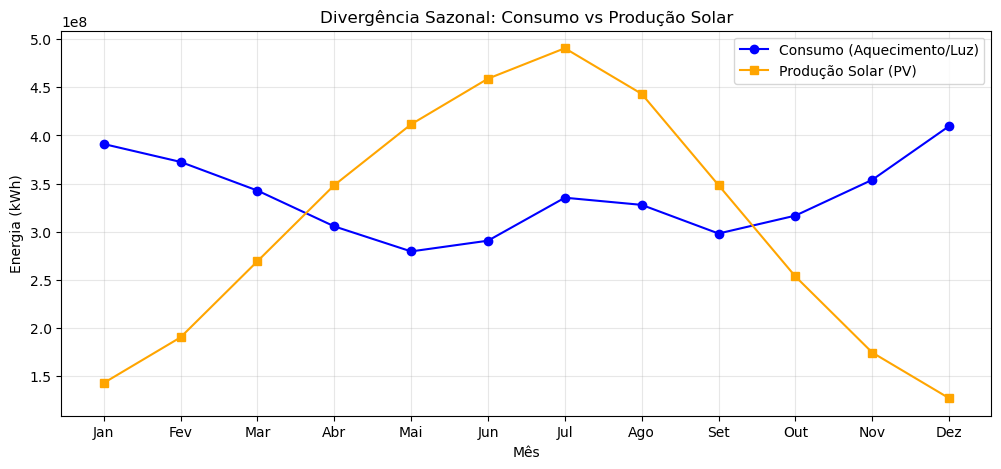

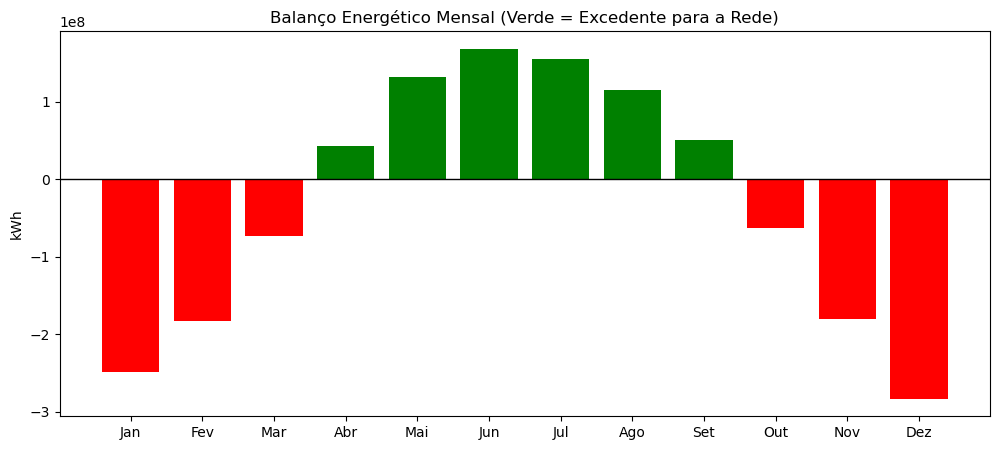


TOTAL ANUAL:
Consumo: 4,022,649,352.73 kWh
Produção: 3,656,700,001.90 kWh
Independência Energética Teórica: 90.9%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DADOS DE BASE (FEVEREIRO)
# ============================================================
# Usando o valor total de consumo de fevereiro que indicaste
consumo_fevereiro_total = 372467532.66 

# ============================================================
# 2. DEFINIÇÃO DE FATORES SAZONAIS (DIFERENCIADOS)
# ============================================================

# Consumo: Mais alto no Inverno (aquecimento/luz)
fatores_consumo = {
    "Jan": 1.05, "Fev": 1.00, "Mar": 0.92, "Abr": 0.82,
    "Mai": 0.75, "Jun": 0.78, "Jul": 0.90, "Ago": 0.88,
    "Set": 0.80, "Out": 0.85, "Nov": 0.95, "Dez": 1.10
}

# Produção Fotovoltaica: Mais alta no Verão (Sol/Dias longos)
# Estes fatores são baseados na irradiação típica em Portugal
fatores_producao_fv = {
    "Jan": 0.45, "Fev": 0.60, "Mar": 0.85, "Abr": 1.10,
    "Mai": 1.30, "Jun": 1.45, "Jul": 1.55, "Ago": 1.40,
    "Set": 1.10, "Out": 0.80, "Nov": 0.55, "Dez": 0.40
}

# ============================================================
# 3. CRIAÇÃO DO DATAFRAME MENSAL
# ============================================================

meses = list(fatores_consumo.keys())
dados = []

# Definimos uma "potência instalada" teórica. 
# Exemplo: O sistema produz no total do ano cerca de 80% do que se consome.
target_producao_anual = consumo_fevereiro_total * 0.85 

for mes in meses:
    c_mes = consumo_fevereiro_total * fatores_consumo[mes]
    p_mes = target_producao_anual * fatores_producao_fv[mes]
    
    # Autoconsumo Mensal Simplificado 
    # (Nota: Na realidade é menor pois depende da coincidência horária)
    autoconsumo = min(c_mes, p_mes)
    balanco = p_mes - c_mes
    
    dados.append({
        "Mes": mes,
        "Consumo_kWh": round(c_mes, 2),
        "Producao_FV_kWh": round(p_mes, 2),
        "Balanco_kWh": round(balanco, 2),
        "Autoconsumo_kWh": round(autoconsumo, 2)
    })

df = pd.DataFrame(dados)

# Cálculos de Percentagem
df["Taxa_Autoconsumo_%"] = round((df["Autoconsumo_kWh"] / df["Consumo_kWh"]) * 100, 2)

# ============================================================
# 4. VISUALIZAÇÃO DOS RESULTADOS
# ============================================================

print("\n--- ANÁLISE ENERGÉTICA ANUAL ESTIMADA ---")
print(df)

# Gráfico 1: Consumo vs Produção
plt.figure(figsize=(12, 5))
plt.plot(df["Mes"], df["Consumo_kWh"], marker="o", label="Consumo (Aquecimento/Luz)", color="blue")
plt.plot(df["Mes"], df["Producao_FV_kWh"], marker="s", label="Produção Solar (PV)", color="orange")
plt.title("Divergência Sazonal: Consumo vs Produção Solar")
plt.xlabel("Mês")
plt.ylabel("Energia (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2: Balanço (Excedente ou Défice)
plt.figure(figsize=(12, 5))
cores = ['green' if x > 0 else 'red' for x in df["Balanco_kWh"]]
plt.bar(df["Mes"], df["Balanco_kWh"], color=cores)
plt.axhline(0, color='black', linewidth=1)
plt.title("Balanço Energético Mensal (Verde = Excedente para a Rede)")
plt.ylabel("kWh")
plt.show()

# ============================================================
# 5. TOTAIS ANUAIS
# ============================================================
total_c = df["Consumo_kWh"].sum()
total_p = df["Producao_FV_kWh"].sum()

print(f"\nTOTAL ANUAL:")
print(f"Consumo: {total_c:,.2f} kWh")
print(f"Produção: {total_p:,.2f} kWh")
print(f"Independência Energética Teórica: {(total_p/total_c)*100:.1f}%")

In [5]:
import pandas as pd

# 1. Carregar os dados
df = pd.read_csv('consumo_anual_estimado_2024.csv', sep=';')
df['Data/Hora'] = pd.to_datetime(df['Data/Hora'])

# 2. Cálculo da Normalização Min-Max
v_max = df['Energia ativa (kWh)'].max()
v_min = df['Energia ativa (kWh)'].min()

# Criar a coluna normalizada (Escala 0-1)
df['Consumo_Normalizado'] = (df['Energia ativa (kWh)'] - v_min) / (v_max - v_min)

# 3. Exportar
df.to_csv('consumo_anual_2024_normalizado.csv', index=False, sep=';')

print("Normalização concluída!")

Normalização concluída!
